In [1]:
import src.sph_cpp as sph
import struct
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

Define simulation parameters

In [61]:
res = 0.5
no_steps = 100
Lx = 5.0
Ly = 5.0
rho0 = 1000.0
kappa = 1.2
v0 = 10
dt = 0.01
c_s = 0.1
gamma_index = 7.0

central_radius = 0.5
boundary_width = 0.1
max_force = 1000



Run simulation

In [62]:
params = sph.SimulationParams(
    res, no_steps, Lx, Ly, rho0, kappa, v0, dt, c_s, gamma_index, central_radius, boundary_width, max_force
)

# Initialize ParticleList
particle_list = sph.ParticleList(params)

# Setup initial conditions
particle_list.init_random()
particle_list.init_mass()
particle_list.init_vel()

# Run simulation
particle_list.integrate()

time,x,y


Read data

In [63]:
def read_all_output(filename):
    frames = []
    with open(filename, "rb") as f:
        while True:
            int_bytes = f.read(4)
            if not int_bytes:
                break  # EOF
            N = struct.unpack("i", int_bytes)[0]

            x_bytes = f.read(8 * N)
            y_bytes = f.read(8 * N)
            if len(x_bytes) < 8 * N or len(y_bytes) < 8 * N:
                print("Warning: Incomplete frame at the end of the file")
                break

            x = np.frombuffer(x_bytes, dtype=np.float64)
            y = np.frombuffer(y_bytes, dtype=np.float64)
            frames.append((x, y))

    return frames

In [64]:
frames = read_all_output("all_output.bin")

In [69]:
h = kappa*res
sigma = 10.0/(7.0*np.pi*h**2)
print(f"{h=}")
print(f"no_particles = {len(frames[0][0])}")
print(f"masses = {rho0*res**2}")

def kernel(q):
     w = np.zeros_like(q)
     w[q>=1.0] = sigma*0.25*(2.0-q[q>1.0])**3
     w[q<1.0] = sigma*(1.0-1.5*q[q<1.0]**2 + 0.75*q[q<1.0]**3)
     return w

def get_density_grid(pos_x, pos_y, Lx, Ly, grid_size=100):
    """Calculates the densities on a grid
    Arguments:
        positions (np.ndarray): positions of all particles
        masses (np.ndarray): masses of all particles
        h (float): smoothing length
        L (float): size of the simulation
        grid_size (int): size of the grid for density calculation.
    Returns:
        x (np.ndarray): 1D array of x coordinates of the grid
        y (np.ndarray): 1D array of y coordinates of the grid.
        density (np.ndarray): 2D array of shape (grid_size, grid_size) containing the density values at each grid point.
    """
    masses = np.zeros(len(pos_x))+rho0*res**2
    # Generate grid
    x = np.linspace(0,Lx,grid_size)
    y = np.linspace(0,Ly,grid_size)
    X,Y = np.meshgrid(x,y)

    # Apply periodic boundary conditions to distances
    dx = (X[:, :, None] - pos_x)
    dx = (dx+Lx/2)%Lx - Lx/2
    dy = (Y[:, :, None] - pos_y)
    dy = (dy+Ly/2)%Ly - Ly/2

    distances = np.sqrt(dx**2+dy**2)

    # Calculate density
    density = np.sum(masses*kernel(distances), axis=2)
    return x,y,density

h=0.6
no_particles = 100
masses = 250.0


(100,) (100,) (100, 100)


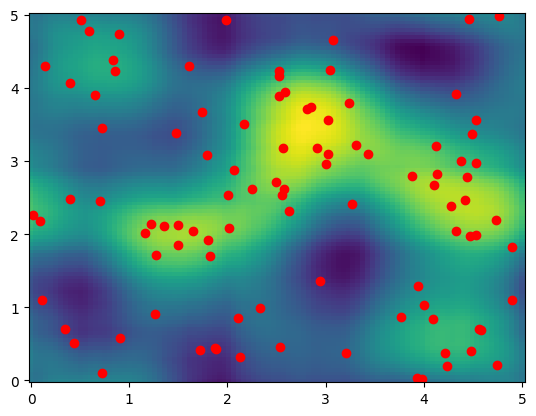

In [66]:
pos_x = np.random.random(100)*Lx
pos_y = np.random.random(100)*Ly

x,y,rho = get_density_grid(pos_x, pos_y, Lx, Ly)
print(x.shape, y.shape, rho.shape)

fig, ax = plt.subplots()
ax.pcolor(x,y,rho)
ax.scatter(pos_x, pos_y, color="red")

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


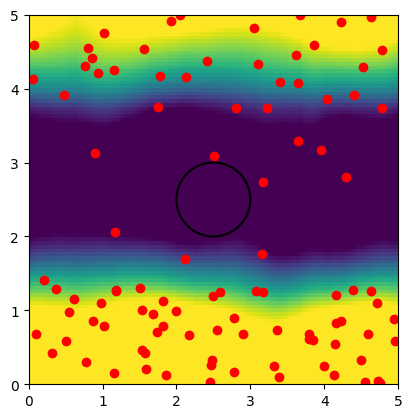

In [68]:
idx = 1
fig, ax = plt.subplots()
ax.set_xlim(0,Lx)
ax.set_ylim(0,Ly)
ax.set_aspect("equal")

# Plot particles
particles, = ax.plot(frames[0][0], frames[0][1], linestyle="None", marker="o", color="red")

# Plot central object
phi = np.linspace(0,2*np.pi,100)
ax.plot(Lx/2.0+central_radius*np.cos(phi), Ly/2.0+central_radius*np.sin(phi), color="black")

# Plot density
x,y,rho = get_density_grid(frames[0][0], frames[0][1], Lx, Ly)
density = ax.pcolor(x,y,rho)

def update(frame):
    print(frame)
    particles.set_xdata(frames[frame][0])
    particles.set_ydata(frames[frame][1])
    x,y,rho = get_density_grid(frames[frame][0], frames[frame][1], Lx, Ly)
    density.set_array(rho)

anim = FuncAnimation(fig, update, len(frames))
anim.save("figures/cpp_animation.mp4")
plt.show()